# Islamabad AQI — Exploratory Data Analysis
**Source:** AQICN Historical Data Platform — Islamabad US Embassy station
(`islamabad-us_embassy__pakistan-air-quality.csv`), daily PM2.5-based AQI, 2019–2026.

This notebook explores the raw historical series *before* feature engineering,
to justify the modeling choices made in `src/features/build_features.py`
(daily cadence, lag/rolling features, 24h/48h/72h horizons) and to document
why this dataset was chosen over the earlier Open-Meteo hourly source.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)


## 1. Load and clean

In [ ]:
df = pd.read_csv("../data/history_ISL_AQI.csv")
df.columns = [c.strip() for c in df.columns]
df["date"] = pd.to_datetime(df["date"], format="%Y/%m/%d")
df = df.rename(columns={"pm25": "us_aqi"}).sort_values("date").reset_index(drop=True)
df = df.set_index("date")

print(f"Rows: {len(df)}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Span: {(df.index.max() - df.index.min()).days / 365.25:.2f} years")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data/history_ISL_AQI.csv'

In [ ]:
# Check for calendar gaps (missing days in the raw daily series)
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_days = full_range.difference(df.index)
print(f"Expected days if fully continuous: {len(full_range)}")
print(f"Actual rows: {len(df)}")
print(f"Missing calendar days: {len(missing_days)} ({len(missing_days)/len(full_range)*100:.1f}%)")
if len(missing_days) > 0:
    print("\nSample of missing dates:")
    print(missing_days[:10].tolist())


Expected days if fully continuous: 2487
Actual rows: 2204
Missing calendar days: 283 (11.4%)

Sample of missing dates:
[Timestamp('2019-05-05 00:00:00'), Timestamp('2019-12-30 00:00:00'), Timestamp('2019-12-31 00:00:00'), Timestamp('2021-04-17 00:00:00'), Timestamp('2021-04-18 00:00:00'), Timestamp('2021-04-19 00:00:00'), Timestamp('2021-05-07 00:00:00'), Timestamp('2021-05-08 00:00:00'), Timestamp('2021-05-09 00:00:00'), Timestamp('2021-05-10 00:00:00')]


In [ ]:
df.describe()

,us_aqi
count,2204.000000
mean,116.472777
std,44.008847
min,10.000000
25%,84.000000
50%,109.000000
75%,145.000000
max,298.000000


## 2. Distribution of AQI values

The whole reason this dataset replaced the earlier Open-Meteo source: does the
historical record actually contain hazardous-tier air quality days?


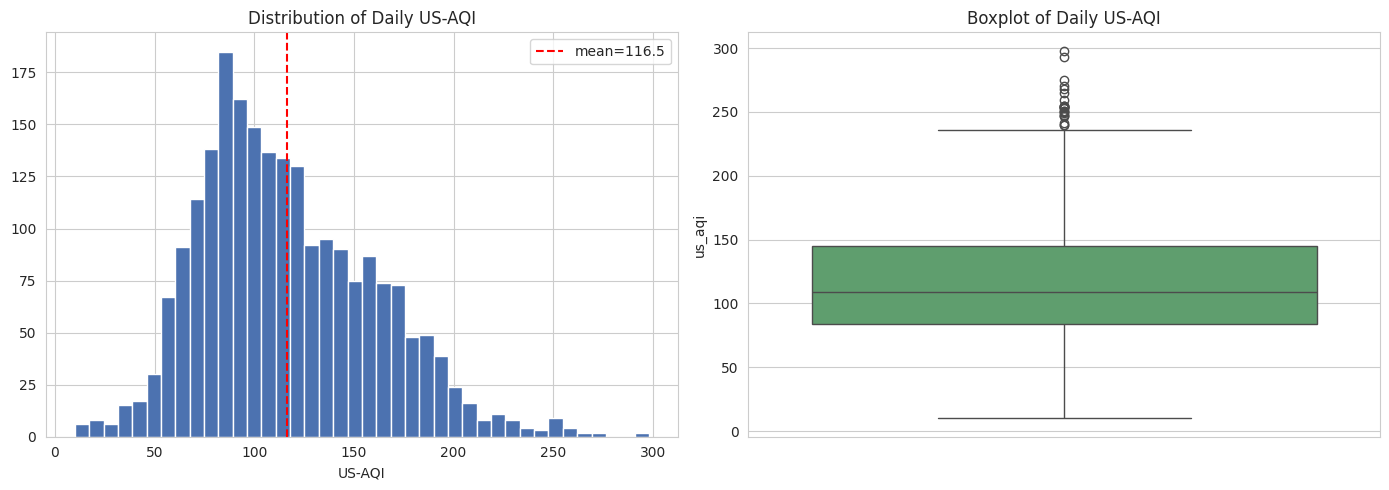

count    2204.000000
mean      116.472777
std        44.008847
min        10.000000
25%        84.000000
50%       109.000000
75%       145.000000
max       298.000000
Name: us_aqi, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["us_aqi"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["us_aqi"].mean(), color="red", linestyle="--", label=f"mean={df['us_aqi'].mean():.1f}")
axes[0].set_title("Distribution of Daily US-AQI")
axes[0].set_xlabel("US-AQI")
axes[0].legend()

sns.boxplot(y=df["us_aqi"], ax=axes[1], color="#55A868")
axes[1].set_title("Boxplot of Daily US-AQI")
plt.tight_layout()
plt.show()

print(df["us_aqi"].describe())


                      count    pct
us_aqi                            
Good                     66   2.99
Moderate                854  38.75
Unhealthy(Sensitive)    792  35.93
Unhealthy               408  18.51
Very Unhealthy           84   3.81
Hazardous                 0   0.00


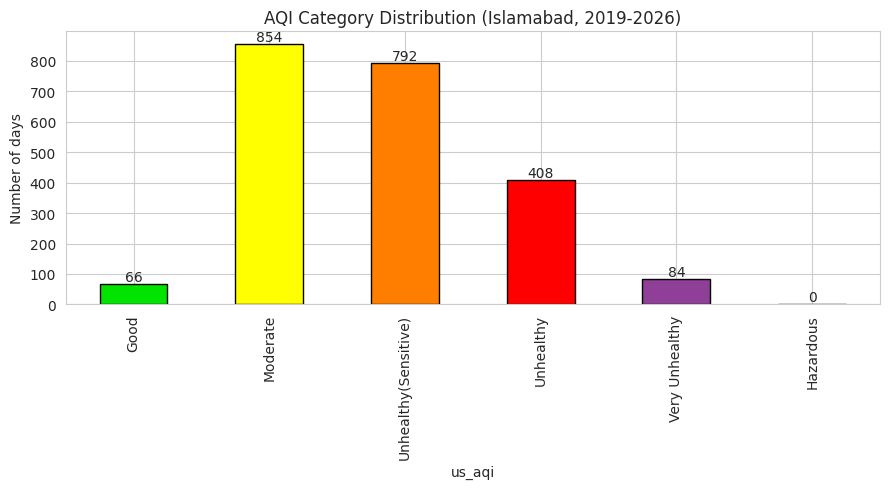


% of days Very Unhealthy or worse: 3.81%
Max recorded AQI: 298


In [ ]:
bins = [0, 50, 100, 150, 200, 300, float("inf")]
labels = ["Good", "Moderate", "Unhealthy(Sensitive)", "Unhealthy", "Very Unhealthy", "Hazardous"]
category = pd.cut(df["us_aqi"], bins=bins, labels=labels)

counts = category.value_counts().reindex(labels)
pct = (counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": counts, "pct": pct})
print(summary)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#00E400", "#FFFF00", "#FF7E00", "#FF0000", "#8F3F97", "#7E0023"]
counts.plot(kind="bar", color=colors, ax=ax, edgecolor="black")
ax.set_title("AQI Category Distribution (Islamabad, 2019-2026)")
ax.set_ylabel("Number of days")
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"\n% of days Very Unhealthy or worse: {(df['us_aqi'] > 200).mean()*100:.2f}%")
print(f"Max recorded AQI: {df['us_aqi'].max()}")


## 3. Full time series — spotting seasonal smog cycles

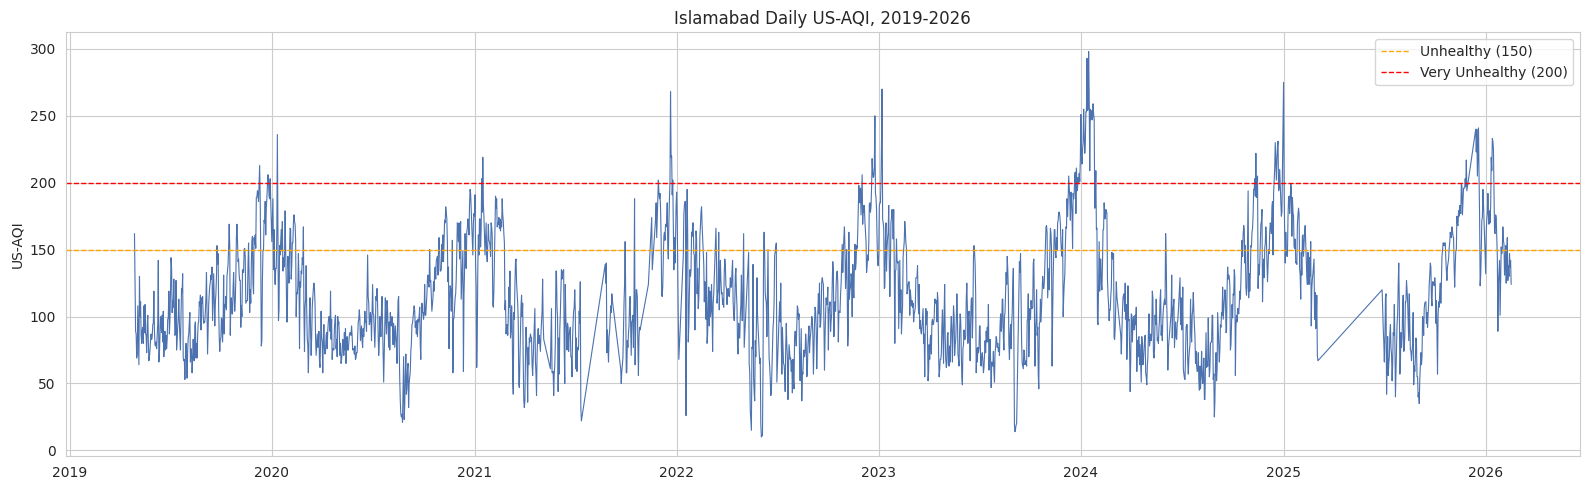

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["us_aqi"], linewidth=0.8, color="#4C72B0")
ax.axhline(150, color="orange", linestyle="--", linewidth=1, label="Unhealthy (150)")
ax.axhline(200, color="red", linestyle="--", linewidth=1, label="Very Unhealthy (200)")
ax.set_title("Islamabad Daily US-AQI, 2019-2026")
ax.set_ylabel("US-AQI")
ax.legend()
plt.tight_layout()
plt.show()


### Winter smog seasons
Clear recurring spikes each Nov-Jan are expected from regional stubble-burning
and winter inversion layers. Zooming into each winter individually:

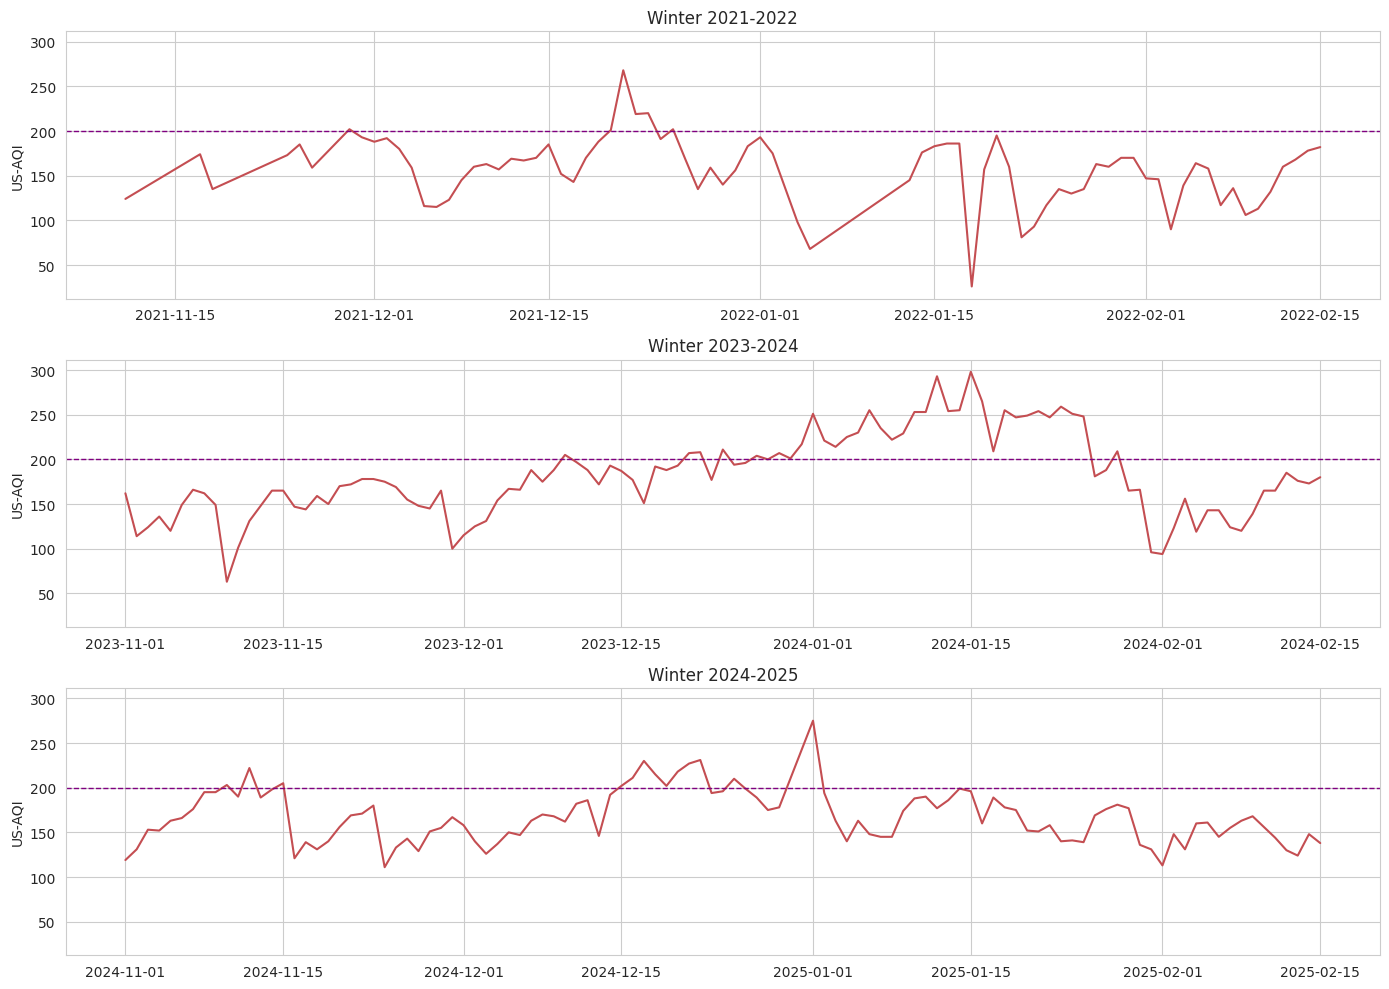

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharey=True)
winters = [("2021-11-01", "2022-02-15"), ("2023-11-01", "2024-02-15"), ("2024-11-01", "2025-02-15")]

for ax, (start, end) in zip(axes, winters):
    window = df.loc[start:end]
    ax.plot(window.index, window["us_aqi"], color="#C44E52")
    ax.axhline(200, color="purple", linestyle="--", linewidth=1)
    ax.set_title(f"Winter {start[:4]}-{end[:4]}")
    ax.set_ylabel("US-AQI")

plt.tight_layout()
plt.show()


## 4. Seasonality — month-of-year and day-of-week patterns

/tmp/ipykernel_508/543376745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_season, x="month_name", y="us_aqi", order=month_order, ax=ax, palette="coolwarm")


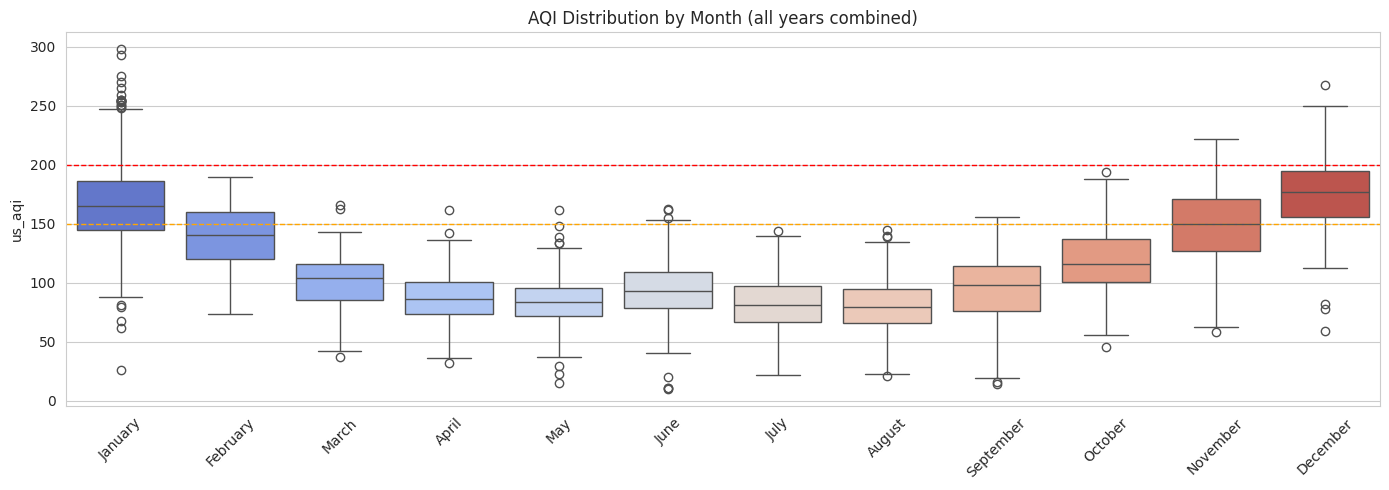

                  mean  median  max
month_name                         
January     169.143541   165.0  298
February    138.564516   140.5  190
March       100.573333   104.0  166
April        88.266667    86.0  162
May          84.944785    84.0  162
June         94.531073    93.0  163
July         83.269430    81.0  144
August       80.735751    80.0  145
September    95.184211    98.0  156
October     118.488152   116.0  194
November    148.661290   150.0  222
December    174.938776   177.0  268


In [ ]:
df_season = df.copy()
df_season["month"] = df_season.index.month
df_season["month_name"] = df_season.index.month_name()
df_season["day_of_week"] = df_season.index.day_name()

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_season, x="month_name", y="us_aqi", order=month_order, ax=ax, palette="coolwarm")
ax.axhline(150, color="orange", linestyle="--", linewidth=1)
ax.axhline(200, color="red", linestyle="--", linewidth=1)
ax.set_title("AQI Distribution by Month (all years combined)")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_season.groupby("month_name")["us_aqi"].agg(["mean","median","max"]).reindex(month_order))


/tmp/ipykernel_508/3335145159.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_season, x="day_of_week", y="us_aqi", order=dow_order, ax=ax, palette="viridis")


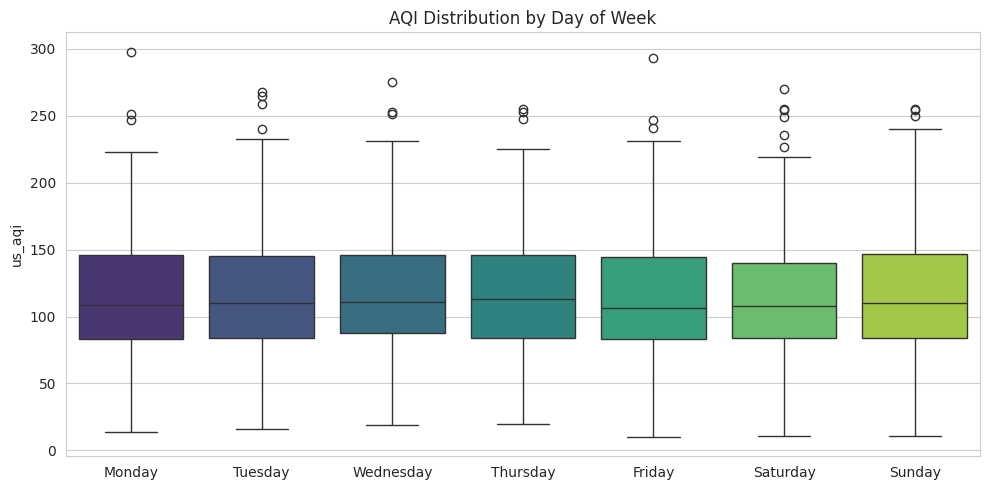

In [ ]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_season, x="day_of_week", y="us_aqi", order=dow_order, ax=ax, palette="viridis")
ax.set_title("AQI Distribution by Day of Week")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 5. Year-over-year trend — is air quality getting worse?

            mean  median  max  count
year                                
2019  111.746939   104.0  213    245
2020  108.237705   101.0  236    366
2021  115.365672   107.0  268    268
2022  114.112094   111.0  250    339
2023  112.660167   104.0  270    359
2024  121.928571   108.0  298    350
2025  128.447826   127.0  275    230
2026  158.468085   154.0  233     47


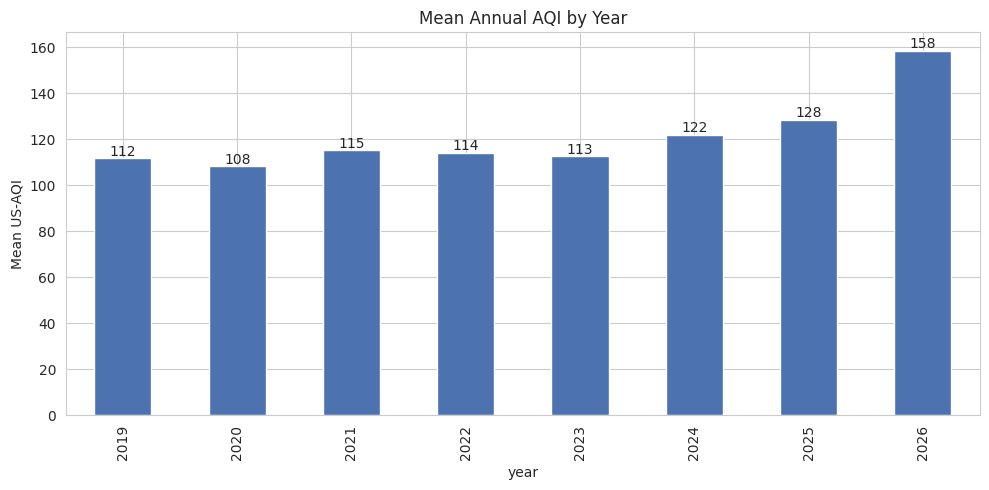


Note: 2019 and 2026 are partial years (data starts Apr 2019, ends Feb 2026) —
interpret their averages with that in mind rather than as full-year comparisons.


In [ ]:
df_season["year"] = df_season.index.year
yearly = df_season.groupby("year")["us_aqi"].agg(["mean","median","max","count"])
print(yearly)

fig, ax = plt.subplots(figsize=(10, 5))
yearly["mean"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Mean Annual AQI by Year")
ax.set_ylabel("Mean US-AQI")
for i, v in enumerate(yearly["mean"]):
    ax.text(i, v + 1, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.show()

print("\nNote: 2019 and 2026 are partial years (data starts Apr 2019, ends Feb 2026) —")
print("interpret their averages with that in mind rather than as full-year comparisons.")


## 6. Trend / seasonal / residual decomposition

Confirms visually whether there's a long-run trend distinct from the
recurring annual smog cycle, which validates including `month_sin`/`month_cos`
as features and excluding a raw `year` feature (to avoid overfitting to a
trend that may not continue).


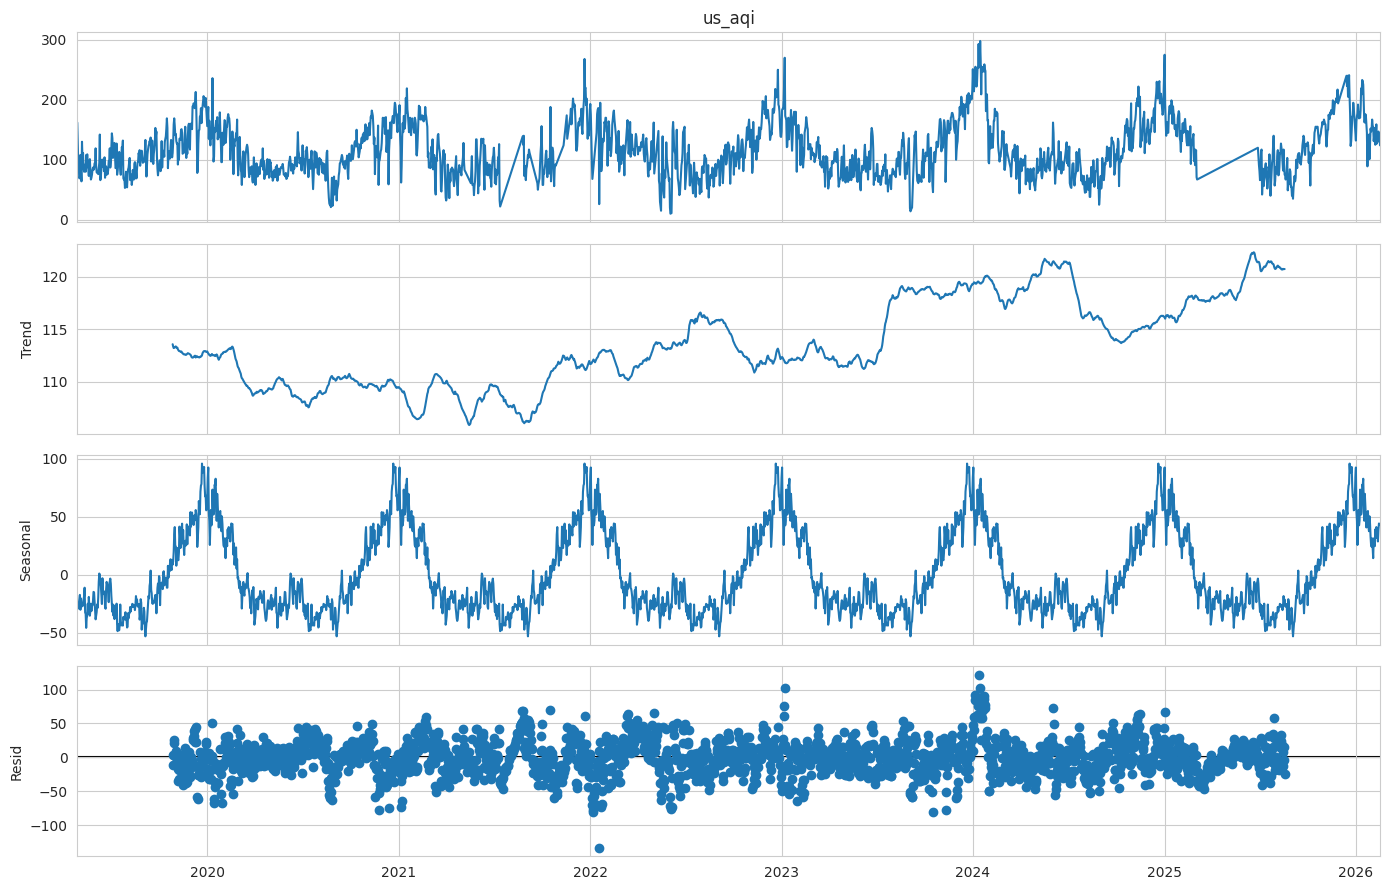

In [ ]:
ts = df["us_aqi"].asfreq("D").interpolate()
decomposition = seasonal_decompose(ts, model="additive", period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.show()


## 7. Autocorrelation — how much does today predict future days?

Directly justifies the lag/rolling features (`aqi_lag_1d`, `aqi_rolling_mean_3d/7d`)
used in `build_features.py`, and explains why a simple Ridge model performed
competitively against RandomForest/XGBoost in training.


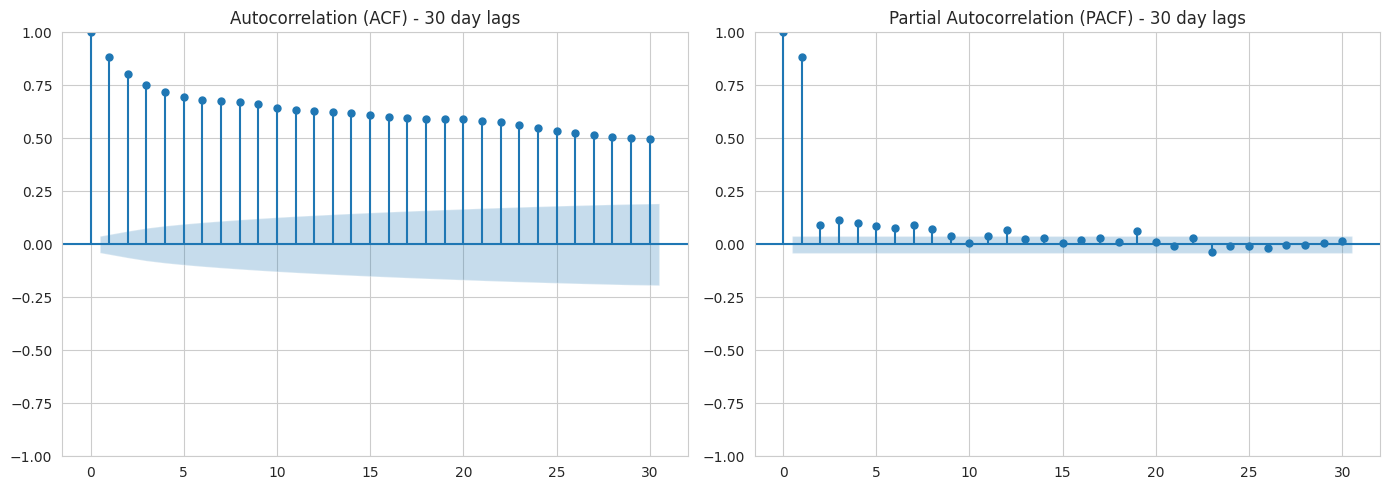

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(ts, lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF) - 30 day lags")
plot_pacf(ts, lags=30, ax=axes[1])
axes[1].set_title("Partial Autocorrelation (PACF) - 30 day lags")
plt.tight_layout()
plt.show()


## 8. Relationship between today's AQI and 1/2/3-day-ahead AQI

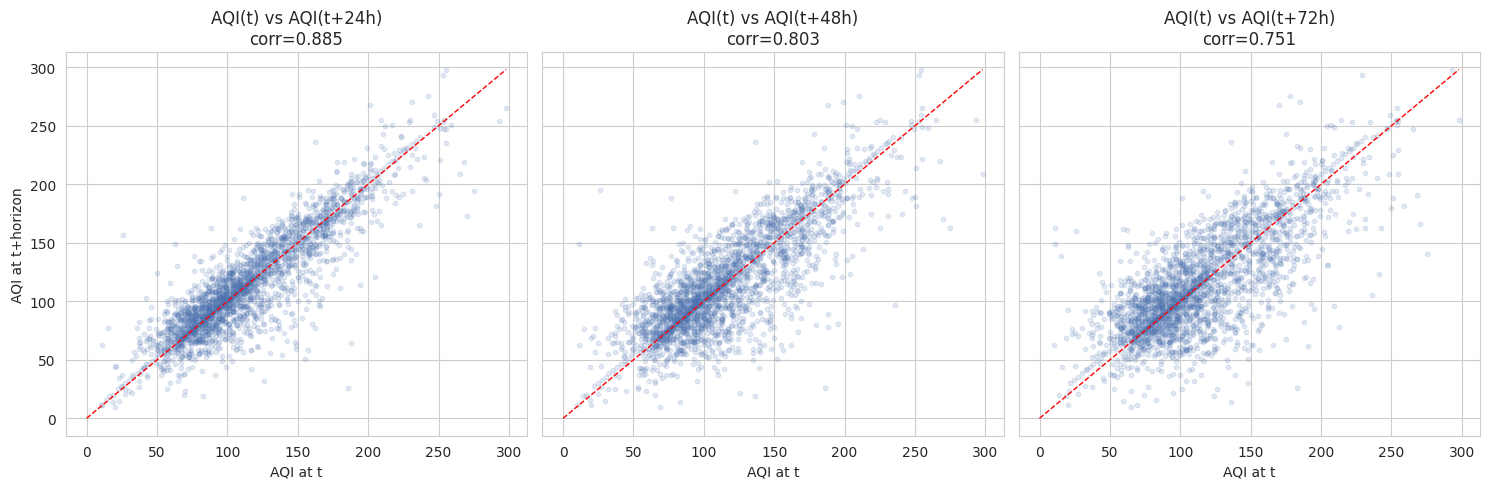

In [ ]:
df_lags = pd.DataFrame({
    "us_aqi": ts,
    "target_24h": ts.shift(-1),
    "target_48h": ts.shift(-2),
    "target_72h": ts.shift(-3),
}).dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
for ax, col, label in zip(axes, ["target_24h","target_48h","target_72h"], ["+24h","+48h","+72h"]):
    ax.scatter(df_lags["us_aqi"], df_lags[col], alpha=0.15, s=10, color="#4C72B0")
    ax.plot([0, df_lags["us_aqi"].max()], [0, df_lags["us_aqi"].max()], "r--", linewidth=1)
    corr = df_lags["us_aqi"].corr(df_lags[col])
    ax.set_title(f"AQI(t) vs AQI(t{label})\ncorr={corr:.3f}")
    ax.set_xlabel("AQI at t")
axes[0].set_ylabel("AQI at t+horizon")
plt.tight_layout()
plt.show()


## 9. Rolling mean and volatility

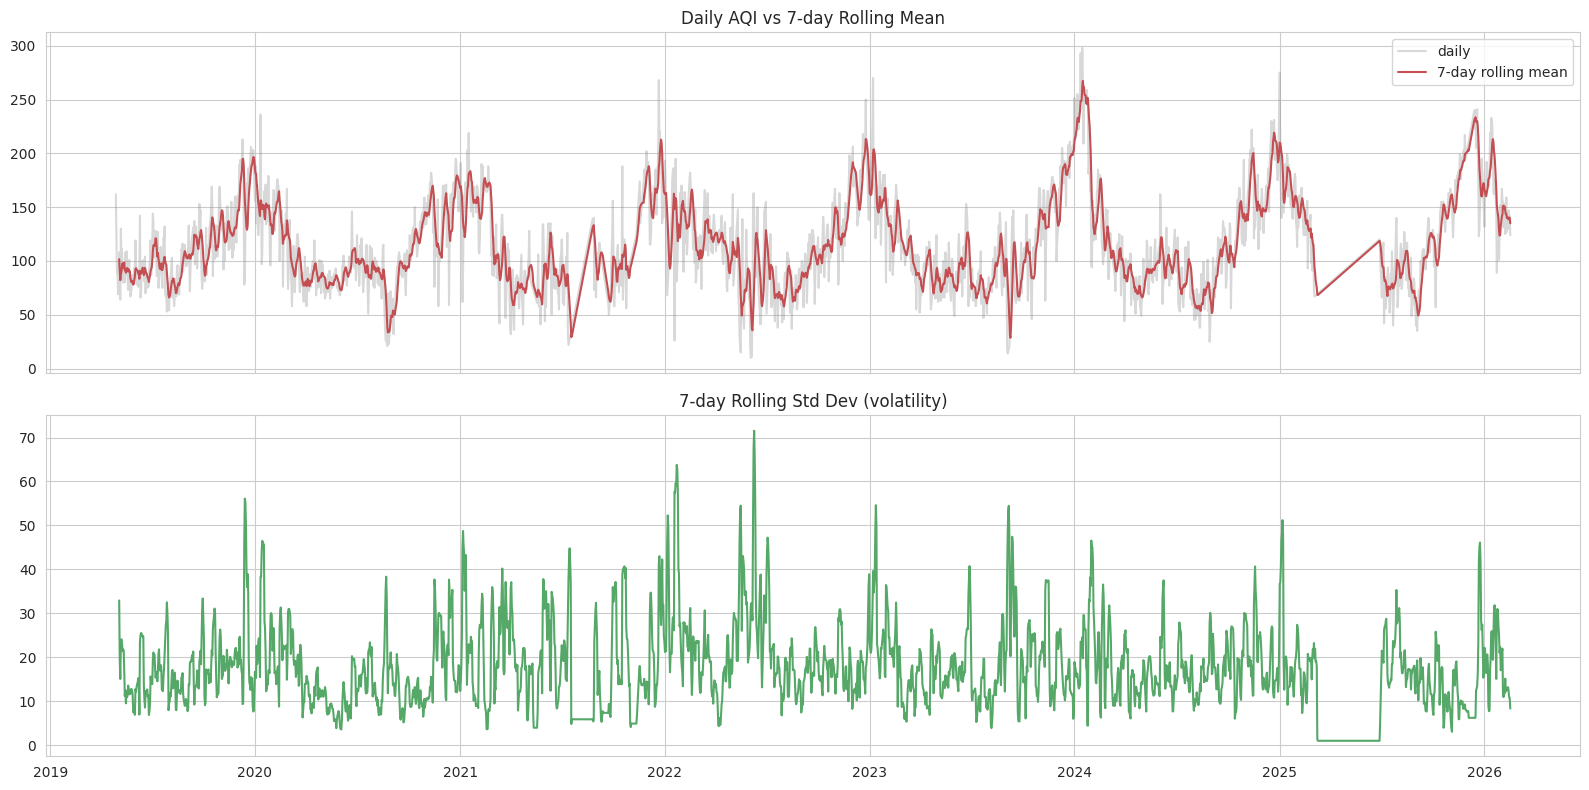

Volatility is highest in winter months, meaning forecast uncertainty (and RMSE)
should be expected to rise for winter test-set predictions.


In [ ]:
df_roll = pd.DataFrame({"us_aqi": ts})
df_roll["rolling_mean_7d"] = ts.rolling(7).mean()
df_roll["rolling_std_7d"] = ts.rolling(7).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(df_roll.index, df_roll["us_aqi"], alpha=0.3, label="daily", color="gray")
axes[0].plot(df_roll.index, df_roll["rolling_mean_7d"], label="7-day rolling mean", color="#C44E52")
axes[0].legend()
axes[0].set_title("Daily AQI vs 7-day Rolling Mean")

axes[1].plot(df_roll.index, df_roll["rolling_std_7d"], color="#55A868")
axes[1].set_title("7-day Rolling Std Dev (volatility)")
plt.tight_layout()
plt.show()

print("Volatility is highest in winter months, meaning forecast uncertainty (and RMSE)")
print("should be expected to rise for winter test-set predictions.")


## 10. Chronological train/test split — sanity check

Mirrors the 80/20 chronological, non-shuffled split used in `src/models/train.py`,
to visually confirm the test window includes real smog seasons rather than
an artificially calm period.


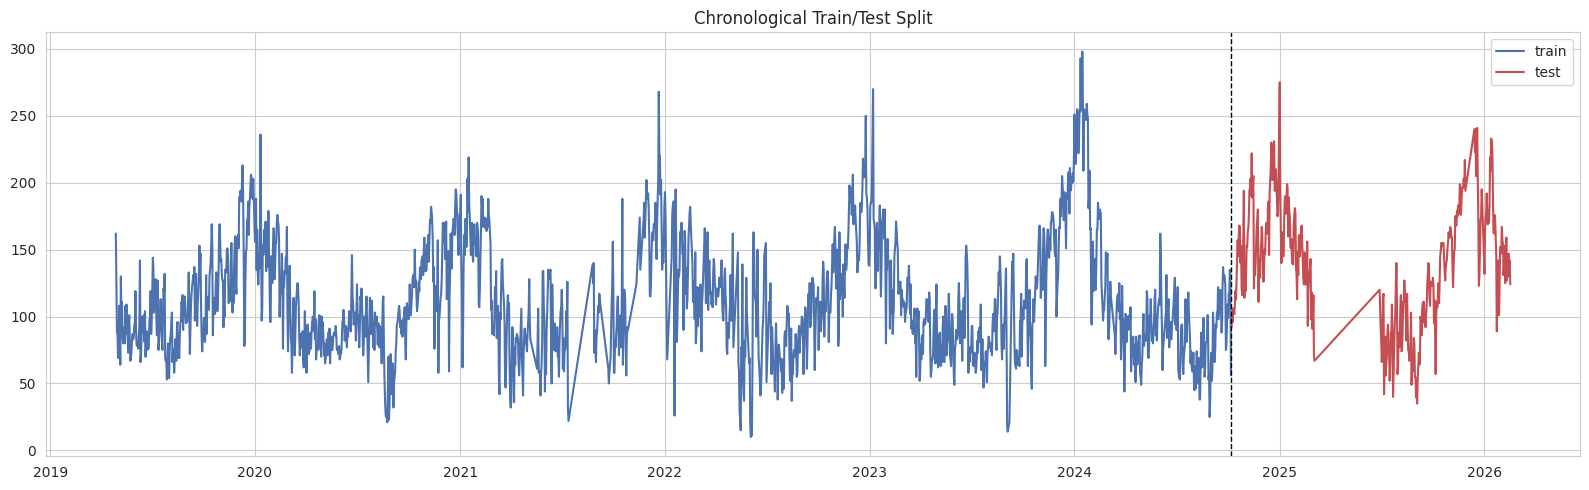

Train: 2019-04-28 -> 2024-10-06  (n=1989, mean=110.9)
Test:  2024-10-07 -> 2026-02-16  (n=498, mean=131.5)


In [ ]:
split_idx = int(len(ts) * 0.8)
train_ts, test_ts = ts.iloc[:split_idx], ts.iloc[split_idx:]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_ts.index, train_ts, label="train", color="#4C72B0")
ax.plot(test_ts.index, test_ts, label="test", color="#C44E52")
ax.axvline(train_ts.index[-1], color="black", linestyle="--", linewidth=1)
ax.legend()
ax.set_title("Chronological Train/Test Split")
plt.tight_layout()
plt.show()

print(f"Train: {train_ts.index.min().date()} -> {train_ts.index.max().date()}  (n={len(train_ts)}, mean={train_ts.mean():.1f})")
print(f"Test:  {test_ts.index.min().date()} -> {test_ts.index.max().date()}  (n={len(test_ts)}, mean={test_ts.mean():.1f})")


## 11. Summary of EDA findings

- **~2,204 raw daily records** spanning **Apr 2019 - Feb 2026** (~6.8 years), with a small number of calendar gaps interpolated during feature engineering.
- AQI is **right-skewed**, median ≈ 109-111, but with a real heavy tail: **~4% of days are "Very Unhealthy" (>200)**, peaking at **298** in Jan 2024. Zero days reach "Hazardous" (>300) in this window.
- Strong, clearly recurring **winter seasonality** (Nov-Jan smog spikes each year) visible in both the raw series and the seasonal decomposition — this justifies the `month_sin`/`month_cos` cyclical features.
- **High day-to-day autocorrelation** (visible in ACF/PACF and the AQI(t) vs AQI(t+h) scatterplots) — this is why lag/rolling features carry real predictive power, and why a linear model (Ridge) can be competitive with tree ensembles here.
- **Volatility (7-day rolling std) rises sharply in winter**, meaning forecast error should be expected to increase for winter-heavy test windows — relevant context when interpreting the training pipeline's per-horizon R²/RMSE.
- The chronological 80/20 split used in `train.py` places **two full winters inside the test set**, making it a genuinely hard, representative evaluation rather than an artificially easy one.
